# 데이터 전처리단계

In [73]:
pip install torch torchvision numpy matplotlib tqdm

Note: you may need to restart the kernel to use updated packages.


In [74]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt

print("PyTorch version:", torch.__version__)
print("MPS available:", torch.backends.mps.is_available())

PyTorch version: 2.14.0
MPS available: True


In [75]:
from torchvision import datasets

train_dataset = datasets.MNIST(
    root="./data", # MNIST 데이터셋 저장할 경로
    train=True, # 학습용 데이터 가져오겠음
    download=True 
)

In [76]:
print(train_dataset)
print("데이터 갯수", len(train_dataset))
print(train_dataset[0]) # (이미지, 라벨)

Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
데이터 갯수 60000
(<PIL.Image.Image image mode=L size=28x28 at 0x12399A510>, 5)


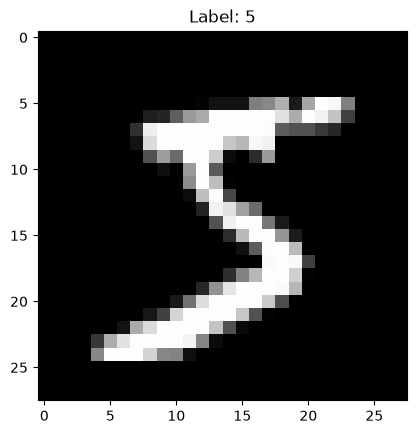

In [77]:
plt.imshow(train_dataset[0][0], cmap="gray")
plt.title(f"Label: {train_dataset[0][1]}")
plt.show()


In [78]:
from torchvision import transforms
to_tensor = transforms.ToTensor() # Tensor로 변환 + 픽셀 크기 스케일링 (0~1)
image_tensor = to_tensor(train_dataset[0][0])

print(type(train_dataset[0][0])) # <class 'PIL.Image.Image'>
print(type(image_tensor)) # <class 'torch.Tensor'>
print(image_tensor.shape) # torch.Size([1, 28, 28])
print("최솟값:", image_tensor.min()) 
print("최댓값:", image_tensor.max())


<class 'PIL.Image.Image'>
<class 'torch.Tensor'>
torch.Size([1, 28, 28])
최솟값: tensor(0.)
최댓값: tensor(1.)


In [79]:
# 한번 더 Norm 하는 이유는 가우시안 노이즈가 N(0, 1)로 들어가기 때문에,     
# 이미지도 N(0, 1)로 맞춰주기 위해서임
normalize = transforms.Normalize(
    mean=(0.5,),
    std=(0.5,)
)

normalized_image = normalize(image_tensor)

print("최솟값:", normalized_image.min())
print("최댓값:", normalized_image.max())

최솟값: tensor(-1.)
최댓값: tensor(1.)


In [80]:
# 여러 전처리 순서대로 묶어 주기
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])



In [81]:
# 전체 데이터셋 전처리 적용

train_dataset = datasets.MNIST(
    root="./data",
    train=True,
    download=True,
    transform=transform
)


In [82]:
# 여러 데이터 한번에 가져오기위해 DataLoader 사용

from torch.utils.data import DataLoader

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=128,
    shuffle=True
)

In [83]:
images, labels = next(iter(train_loader))
print(images.shape) # torch.Size([128, 1, 28, 28])
print(labels.shape) # torch.Size([128])

torch.Size([128, 1, 28, 28])
torch.Size([128])


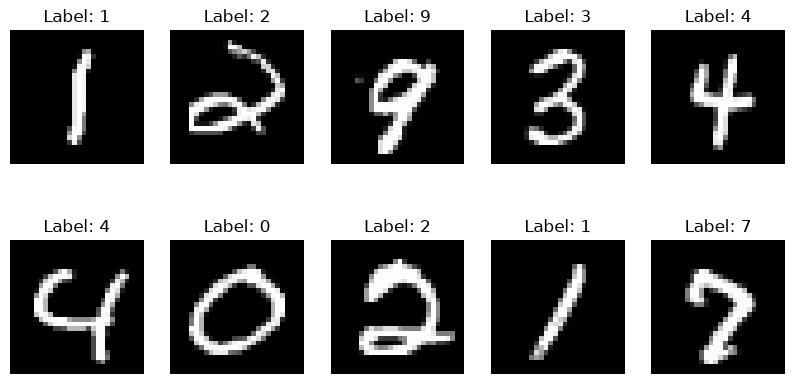

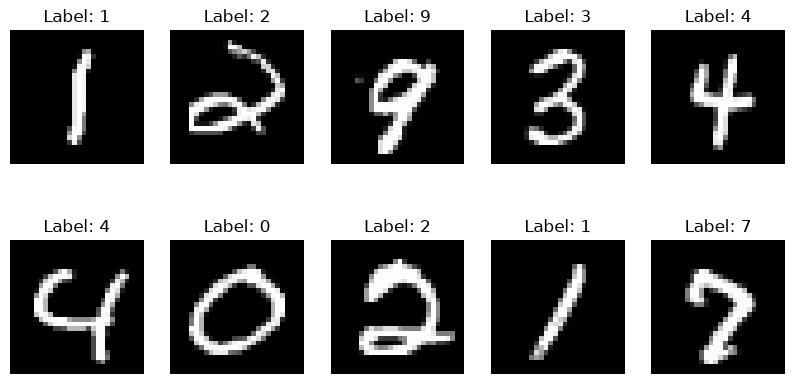

In [84]:
fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i, ax in enumerate(axes.flat):
    img = images[i].squeeze() # (1, 28, 28) -> (28, 28)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"Label: {labels[i].item()}")
    ax.axis("off")

plt.show(0)
                      

# Forward Diffusion



In [85]:
# 이미지에 노이즈를 추가하는 과정
# 아주 작은 노이즈에서 선형적으로 증가시키는 과정

T = 1000 # 노이즈 추가하는 총 과정

beta_start = 0.0001
beta_end = 0.02 

beta = torch.linspace(beta_start, beta_end, T) # 0.0001 ~ 0.02까지 T개로 나눔
# beta_t 는 t번째 단계에서 추가되는 노이즈의 양

print(beta.shape) # torch.Size([1000])
print("처음 베타:", beta[0])
print("마지막 베타:", beta[-1])

torch.Size([1000])
처음 베타: tensor(1.0000e-04)
마지막 베타: tensor(0.0200)


In [86]:
# DDPM 논문에 따라 베타를 알파로 다시 표현

alphas = 1-beta # 특정 t에서 이전 이미지 신호를 얼마나 유지할지

print("처음 알파:", alphas[0])
print("마지막 알파:", alphas[-1])

처음 알파: tensor(0.9999)
마지막 알파: tensor(0.9800)


In [87]:
# DDPM 논문에서 X_0 -> X_t로 한번에 표현할 수 있는 식 구현
alpha_bars = torch.cumprod(alphas, dim=0) # 누적곱

print("shape:", alpha_bars.shape)
print("t=0:", alpha_bars[0])
print("t=99:", alpha_bars[99])
print("t=499:", alpha_bars[499])
print("t=999:", alpha_bars[999])

shape: torch.Size([1000])
t=0: tensor(0.9999)
t=99: tensor(0.8970)
t=499: tensor(0.0786)
t=999: tensor(4.0358e-05)


In [88]:
# 이미지 한장에 노이즈 실제로 입혀보기
x_0, label = train_dataset[0] # (이미지, 라벨)

noise = torch.randn_like(x_0)

print("x_0 shape:", x_0.shape) # torch.Size([1, 28, 28]
print("noise shape:", noise.shape) # torch.Size([1, 28, 28])

t = 500 # 노이즈 추가 단계
x_t = (
    torch.sqrt(alpha_bars[t]) * x_0 + torch.sqrt(1-alpha_bars[t]) * noise
)
print("x_t shape:", x_t.shape) # torch.Size([1, 28, 28])

x_0 shape: torch.Size([1, 28, 28])
noise shape: torch.Size([1, 28, 28])
x_t shape: torch.Size([1, 28, 28])


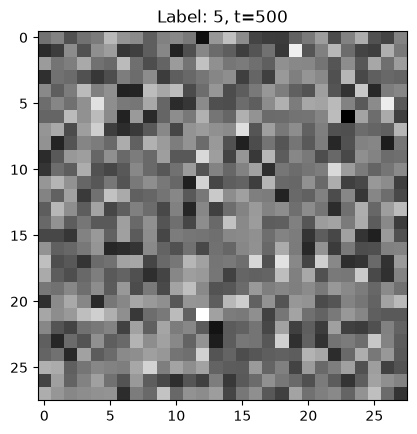

In [89]:
plt.imshow(x_t.squeeze(), cmap="gray")
plt.title(f"Label: {label}, t={t}")
plt.show()


In [90]:
# Forward Diffusion 전체 흐름

def forward_diffusion(x_0, t):
    noise = torch.randn_like(x_0)

    x_t = (
        torch.sqrt(alpha_bars[t]) * x_0 + torch.sqrt(1-alpha_bars[t]) * noise
    )
    return x_t




In [91]:
x_t = forward_diffusion(x_0, t=500)


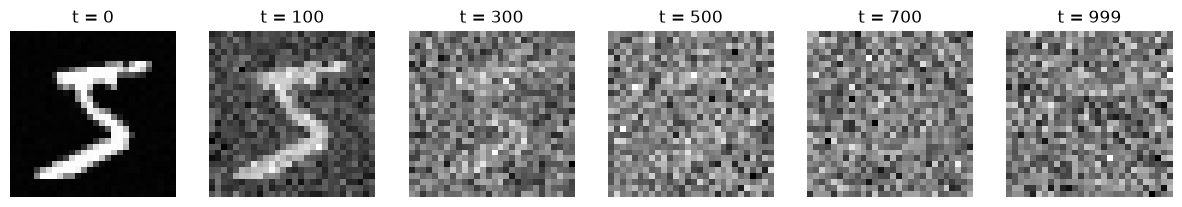

In [92]:
timesteps = [0, 100, 300, 500, 700, 999]

fig, axes = plt.subplots(1, len(timesteps), figsize=(15, 5))

for t, ax in zip(timesteps, axes):
    x_t = forward_diffusion(x_0, t)

    ax.imshow(x_t.squeeze(), cmap="gray")
    ax.set_title(f"t = {t}")
    ax.axis("off")

plt.show()

In [93]:

batch_size = images.shape[0]

t = torch.randint(
    low=0,
    high=T,
    size=(batch_size,)
) # 랜덤한 timestep 배치에 들어가있는 이미지 수 만큼

print(t.shape) # torch.Size([128])
print(t[:10]) 

torch.Size([128])
tensor([812, 858, 800, 611, 931, 102, 903,  67, 554, 141])


In [94]:
noise = torch.randn_like(images)

alpha_bar_t = alpha_bars[t].view(-1, 1, 1, 1) # (128,) -> (128, 1, 1, 1)로 변환

print("alpha_bar_t shape:", alpha_bar_t.shape) # torch.Size([128])

alpha_bar_t shape: torch.Size([128, 1, 1, 1])


In [95]:
# images       : [128, 1, 28, 28]   ← 원본 x₀
# noise        : [128, 1, 28, 28]   ← 이미지별 ε
# alpha_bar_t  : [128, 1, 1, 1]     ← 이미지별 t에 해당하는 ᾱₜ

x_t = (
    torch.sqrt(alpha_bar_t) * images + torch.sqrt(1-alpha_bar_t) * noise
)

print("x_t shape:", x_t.shape) # torch.Size([128, 1, 28, 28])

x_t shape: torch.Size([128, 1, 28, 28])


# U-Net Backbone

In [96]:
# Time Embedding 구현
import math

time_dim = 128
half_dim = time_dim/2 # 절반은 sin, 절반은 cos

freqs = torch.exp(
    -math.log(10000) * torch.arange(half_dim) / half_dim
) # t를 표현하기 위한 서로다른 주파수


print("freqs shape:", freqs.shape) # torch.Size([64])
print("freqs[:10]:", freqs[:10])

freqs shape: torch.Size([64])
freqs[:10]: tensor([1.0000, 0.8660, 0.7499, 0.6494, 0.5623, 0.4870, 0.4217, 0.3652, 0.3162,
        0.2738])


In [97]:
# t에 주파수 곱해주기

t_expanded = t[:,None] # (128,) -> (128, 1)
freqs_expanded = freqs[None,:] # (64,) -> (1, 64)

arg = t_expanded * freqs_expanded

print("arg shape:", arg.shape) # torch.Size([128, 64])

# sin, cos 적용
time_emb = torch.cat([
    torch.sin(arg),
    torch.cos(arg)
], dim=1)

print("time_emb shape:", time_emb.shape) # torch.Size([128, 128])

arg shape: torch.Size([128, 64])
time_emb shape: torch.Size([128, 128])


In [98]:
import torch.nn as nn

time_mlp = nn.Sequential(
    nn.Linear(128, 256),
    nn.SiLU(),
    nn.Linear(256,256)
)

time_emb = time_mlp(time_emb)
print("time_emb shape:", time_emb.shape) # torch.Size([128, 256])

time_emb shape: torch.Size([128, 256])


In [99]:
class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_dim):
        super().__init__()

        # 첫번째 이미지 특성 처리
        self.conv1 = nn.Conv2d(
            in_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.norm1 = nn.GroupNorm(8, out_channels)

        self.time_proj = nn.Linear(
            time_dim,
            out_channels    
        )

        # 두번째 이미지 특징 처리
        self.conv2 = nn.Conv2d(
            out_channels,
            out_channels,
            kernel_size=3,
            padding=1
        )

        self.norm2 = nn.GroupNorm(8, out_channels)

        self.activation = nn.SiLU()

        if in_channels != out_channels:
            self.skip = nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=1
            )
        else: 
            self.skip = nn.Identity()



 

    def forward(self, x, time_emb):
        h = self.conv1(x)
        h = self.norm1(h)
        h = self.activation(h)

        t = self.time_proj(time_emb) # [B, time_emb_dim] -> [B, out_channels])

        t = t[:, :, None, None] # [B,C] -> [B,C,1,1]

        h = h + t

        h = self.conv2(h)
        h = self.norm2(h)
        h = self.activation(h)

        return h + self.skip(x)

In [100]:
block = ResidualBlock(
    in_channels=32,
    out_channels=64,
    time_dim=256
)

In [101]:
class Downsample(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.conv = nn.Conv2d(
            channels,
            channels,
            kernel_size=4,
            stride=2,
            padding=1
        )
    def forward(self,x):
        return self.conv(x)


In [102]:
class Upsample(nn.Module):
    def __init__(self, channels):
        super().__init__()

        self.conv = nn.ConvTranspose2d(
            channels,
            channels,
            kernel_size=4,
            stride=2,
            padding=1
        )
    def forward(self,x):
        return self.conv(x)

    

In [103]:
import math
import torch
import torch.nn as nn


class TimeEmbedding(nn.Module):
    def __init__(self, emb_dim=128, time_dim=256):
        super().__init__()

        self.emb_dim = emb_dim

        self.mlp = nn.Sequential(
            nn.Linear(emb_dim, time_dim),
            nn.SiLU(),
            nn.Linear(time_dim, time_dim)
        )

    def forward(self, t):

        half_dim = self.emb_dim // 2

        freqs = torch.exp(
            -math.log(10000)
            * torch.arange(
                half_dim,
                device=t.device   # ← 반드시 이거
            )
            / half_dim
        )

        args = t[:, None].float() * freqs[None, :]

        emb = torch.cat([
            torch.sin(args),
            torch.cos(args)
        ], dim=1)


        
        return self.mlp(emb)

In [104]:
class UNet(nn.Module):
    def __init__(self, time_dim):
        super().__init__()

        # 0. Time Embedding
        self.time_embedding = TimeEmbedding(
            emb_dim=128,
            time_dim=time_dim
        )


        # 1. 입력 이미지: 1채널 -> 32채널

        self.input_conv = nn.Conv2d(
            1,32,
            kernel_size=3,
            padding=1
        )

        # 2. Encoder
        self.enc1 = ResidualBlock(32,32,time_dim)
        self.down1 = Downsample(32)

        self.enc2 = ResidualBlock(32,64,time_dim)
        self.down2 = Downsample(64)

        # 3. Bottleneck
        self.middle = ResidualBlock(64,128,time_dim)

        # 4. Decoder

        self.up1 = Upsample(128)

        # up1 : 128 Channel
        # skip1 : 64 Channel
        # concat : 192 Channel

        self.dec1 = ResidualBlock(128 + 64, 64, time_dim)

        self.up2 = Upsample(64)

        # up2: 64 Channel
        # skip1: 32 Channel
        # concat → 96 Channel

        self.dec2 = ResidualBlock(64 + 32, 32, time_dim)

        # 5. 최종 노이즈 예측
        
        self.output_conv = nn.Conv2d(
            32,1,
            kernel_size=1
        )

    def forward(self, x, t):
        time_emb = self.time_embedding(t)

        x = self.input_conv(x)

        h1 = self.enc1(x,time_emb)
        x = self.down1(h1)

        h2 = self.enc2(x,time_emb)
        x = self.down2(h2)

        x = self.middle(x, time_emb)

        x = self.up1(x)

        x = torch.cat([x,h2], dim=1)

        x = self.dec1(x,time_emb)

        x = self.up2(x)

        x = torch.cat([x,h1], dim=1)
        x = self.dec2(x, time_emb)

        x = self.output_conv(x)

        return x
    



        

In [105]:
model = UNet(time_dim=256)


In [106]:
pred_noise = model(x_t,t)
print(pred_noise.shape)

torch.Size([128, 1, 28, 28])


# Loss optimizer


In [107]:
import torch.nn.functional as F

loss = F.mse_loss(pred_noise, noise)

print("Loss", loss.item())

Loss 1.1899672746658325


In [108]:
device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cpu"
)
print("device", device)

model = model.to(device)
alpha_bars = alpha_bars.to(device)

device mps


In [109]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

In [110]:
print("model :", next(model.parameters()).device)
print("x_t   :", x_t.device)
print("t     :", t.device)
print("noise :", noise.device)

model : mps:0
x_t   : cpu
t     : cpu
noise : cpu


In [111]:
loss_history = []
epochs = 10

for epoch in range(epochs):

    model.train()
    total_loss = 0

    for images, _ in train_loader:
        images = images.to(device)

        batch_size = images.shape[0]

        t = torch.randint(
            0,T,(batch_size,),device=device
        )

        noise = torch.randn_like(images)

        alpha_bar_t = alpha_bars[t].view(-1,1,1,1)

        x_t = (torch.sqrt(alpha_bar_t)*images + torch.sqrt(1-alpha_bar_t)*noise)

        pred_noise = model(x_t,t)

        loss = F.mse_loss(pred_noise, noise)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        total_loss = total_loss + loss.item()

    avg_loss = total_loss / len(train_loader)

    loss_history.append(avg_loss)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Loss: {avg_loss:.4f}"
        )
    print(f"Epoch [{epoch}/10] Loss: {loss:.4f}")

Epoch [1/10] Loss: 0.0560
Epoch [0/10] Loss: 0.0410
Epoch [2/10] Loss: 0.0309
Epoch [1/10] Loss: 0.0346
Epoch [3/10] Loss: 0.0284
Epoch [2/10] Loss: 0.0281
Epoch [4/10] Loss: 0.0269
Epoch [3/10] Loss: 0.0352
Epoch [5/10] Loss: 0.0259
Epoch [4/10] Loss: 0.0209
Epoch [6/10] Loss: 0.0253
Epoch [5/10] Loss: 0.0279
Epoch [7/10] Loss: 0.0251
Epoch [6/10] Loss: 0.0241
Epoch [8/10] Loss: 0.0244
Epoch [7/10] Loss: 0.0240
Epoch [9/10] Loss: 0.0244
Epoch [8/10] Loss: 0.0231
Epoch [10/10] Loss: 0.0242
Epoch [9/10] Loss: 0.0243


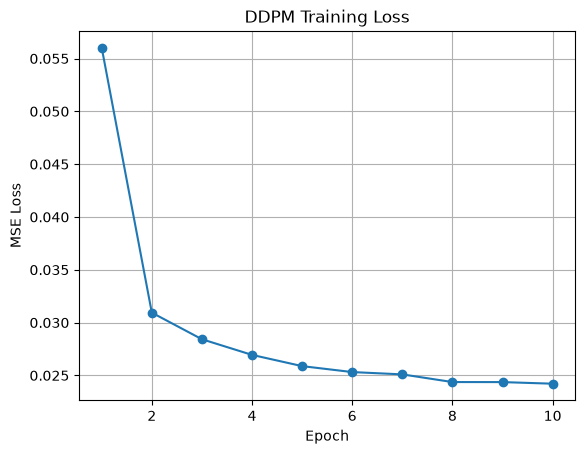

In [112]:
plt.plot(
    range(1, len(loss_history) + 1),
    loss_history,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.title("DDPM Training Loss")
plt.grid()

plt.show()

# Reverse Diffusion

In [113]:
@torch.no_grad()
def reverse_step(model, x_t, t):

    batch_size = x_t.shape[0]

    # 현재 timestep을 batch 크기로 생성
    t_batch = torch.full(
        (batch_size,),
        t,
        device=x_t.device,
        dtype=torch.long
    )

    # 모델이 현재 x_t에 포함된 noise 예측
    pred_noise = model(x_t, t_batch)

    # 현재 timestep의 값들
    beta_t = beta[t]
    alpha_t = alphas[t]
    alpha_bar_t = alpha_bars[t]

    # reverse mean 계산
    mean = (
        1 / torch.sqrt(alpha_t)
    ) * (
        x_t
        -
        (beta_t / torch.sqrt(1 - alpha_bar_t))
        * pred_noise
    )

    # 마지막 t=0에서는 noise를 추가하지 않음
    if t == 0:
        return mean

    # DDPM의 stochastic noise
    noise = torch.randn_like(x_t)

    # posterior variance
    alpha_bar_prev = alpha_bars[t - 1]

    posterior_variance = (
        beta_t
        * (1 - alpha_bar_prev)
        / (1 - alpha_bar_t)
    )

    return mean + torch.sqrt(posterior_variance) * noise


    

In [114]:
betas = beta.to(device)
alphas = alphas.to(device)
alpha_bars = alpha_bars.to(device)

In [115]:
num_samples = 16

x = torch.randn(
    num_samples,
    1,
    28,
    28,
    device=device
)

print(x.shape)

torch.Size([16, 1, 28, 28])


In [116]:
model.eval()

samples = {}

x = torch.randn(
    16,
    1,
    28,
    28,
    device=device
)

save_steps = [999, 750, 500, 250, 100, 0]

for t in reversed(range(T)):

    x = reverse_step(
        model,
        x,
        t
    )

    if t in save_steps:
        samples[t] = x.detach().cpu()

In [117]:
print(samples.keys())
print(samples[0].shape)

dict_keys([999, 750, 500, 250, 100, 0])
torch.Size([16, 1, 28, 28])


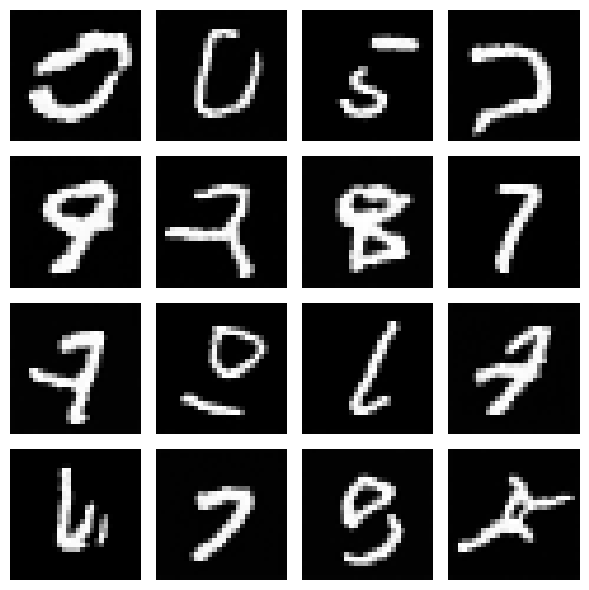

In [118]:
final_images = samples[0]

final_images = (
    final_images.clamp(-1, 1) + 1
) / 2

fig, axes = plt.subplots(4, 4, figsize=(6, 6))

for i, ax in enumerate(axes.flat):
    ax.imshow(
        final_images[i, 0],
        cmap="gray"
    )
    ax.axis("off")

plt.tight_layout()
plt.show()

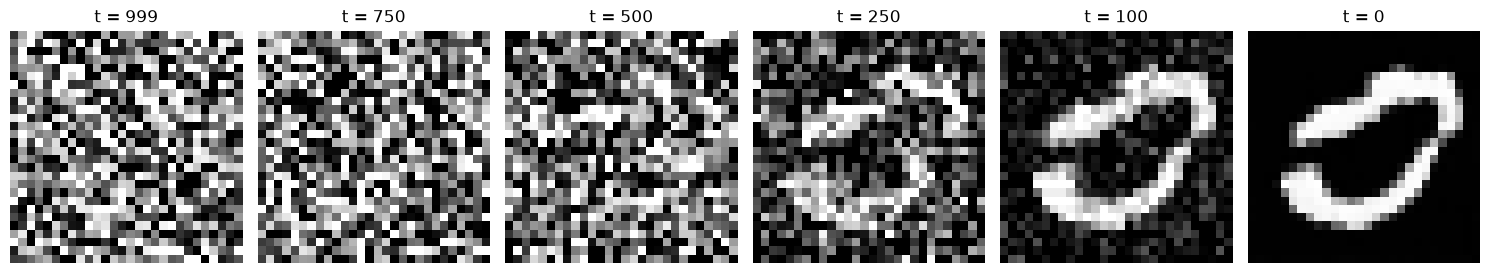

In [119]:
save_steps = [999, 750, 500, 250, 100, 0]

fig, axes = plt.subplots(
    1,
    len(save_steps),
    figsize=(15, 3)
)

sample_idx = 0

for ax, step in zip(axes, save_steps):

    img = samples[step][sample_idx]

    img = (
        img.clamp(-1, 1) + 1
    ) / 2

    ax.imshow(
        img[0],
        cmap="gray"
    )

    ax.set_title(f"t = {step}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [120]:
torch.save(
    model.state_dict(),
    "ddpm_baseline.pth"
)

In [121]:
# 비교할 초기 노이즈 동일하게 유지

num_samples = 16

initial_noise = torch.randn(
    num_samples,
    1,
    28,
    28,
    device=device
)

print(initial_noise.shape)

torch.Size([16, 1, 28, 28])


In [122]:
torch.save(
    initial_noise.cpu(),
    "initial_noise.pt"
)


In [123]:
@torch.no_grad()
def sample_ddpm(model, initial_noise):

    model.eval()

    # 원본 initial_noise를 건드리지 않기 위해 clone
    x = initial_noise.clone().to(device)

    for t in reversed(range(T)):
        x = reverse_step(
            model,
            x,
            t
        )

    return x

In [124]:
baseline_samples = sample_ddpm(
    model,
    initial_noise
)


In [125]:
torch.save(
    baseline_samples.cpu(),
    "baseline_samples.pt"
)

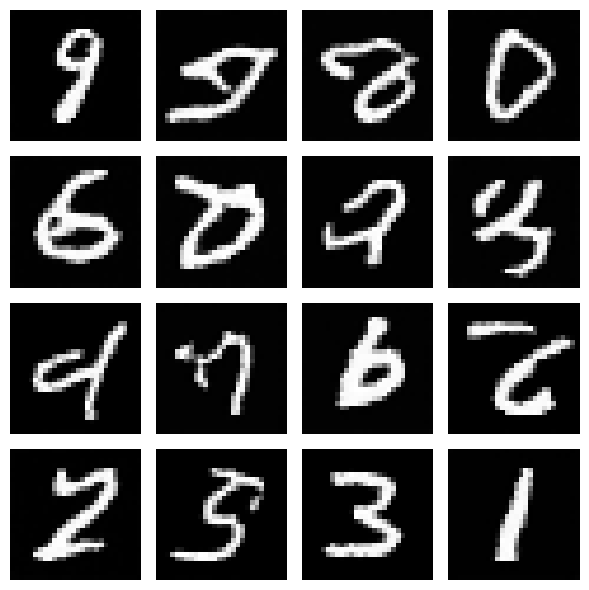

In [126]:
images = (
    baseline_samples
    .detach()
    .cpu()
    .clamp(-1, 1)
    + 1
) / 2

fig, axes = plt.subplots(
    4,
    4,
    figsize=(6, 6)
)

for i, ax in enumerate(axes.flat):

    ax.imshow(
        images[i, 0],
        cmap="gray"
    )

    ax.axis("off")

plt.tight_layout()
plt.show()

# Reward Model

In [127]:
class RewardModel(nn.Module):
    def __init__(self):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1,32,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32,64,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64*7*7,128),
            nn.ReLU(),
            nn.Linear(128,10)
        )

    def forward(self,x):
        x = self.features(x)
        return self.classifier(x)

    

In [128]:
reward_model = RewardModel().to(device)

reward_optimizer = torch.optim.Adam(
    reward_model.parameters(),
    lr = 1e-3
)

In [129]:
test_dataset = datasets.MNIST(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False
)

In [130]:
reward_epochs = 5

for epoch in range(reward_epochs):
    reward_model.train()

    train_loss=0
    correct=0
    total=0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        logits = reward_model(images)

        loss = F.cross_entropy(logits, labels)

        reward_optimizer.zero_grad()
        loss.backward()
        reward_optimizer.step()

        train_loss += loss.item()

        predictions = logits.argmax(dim=1)

        correct += (predictions == labels).sum().item()
        total += labels.size(0)

    avg_loss = total_loss / len(train_loader)

    accuracy = correct / total

    print(
        f"Epoch [{epoch+1}/{reward_epochs}] "
        f"Loss: {avg_loss:.4f} "
        f"Accuracy: {accuracy:.4f}"
    )

Epoch [1/5] Loss: 0.0242 Accuracy: 0.9371
Epoch [2/5] Loss: 0.0242 Accuracy: 0.9835
Epoch [3/5] Loss: 0.0242 Accuracy: 0.9879
Epoch [4/5] Loss: 0.0242 Accuracy: 0.9909
Epoch [5/5] Loss: 0.0242 Accuracy: 0.9930


In [131]:
reward_model.eval()

correct = 0
total = 0

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        logits = reward_model(images)

        predictions = logits.argmax(dim=1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

test_accuracy = correct / total

print(
    f"Test Accuracy: {test_accuracy:.4f}"
)


Test Accuracy: 0.9905


In [132]:
torch.save(
    reward_model.state_dict(),
    "mnist_reward_model.pth"
)

In [133]:
reward_model.eval()

for param in reward_model.parameters():
    param.requires_grad = False

In [134]:
@torch.no_grad()
def get_reward(images):

    logits = reward_model(images)

    probs = torch.softmax(
        logits,
        dim=1
    )

    rewards, predicted_classes = probs.max(
        dim=1
    )

    return rewards, predicted_classes

In [135]:
rewards, classes = get_reward(
    baseline_samples
)

print("Classes :", classes)
print("Rewards :", rewards)
print("Average :", rewards.mean())

Classes : tensor([8, 5, 8, 0, 6, 0, 2, 3, 4, 7, 6, 2, 2, 5, 3, 1], device='mps:0')
Rewards : tensor([0.8059, 0.8606, 0.7033, 0.9993, 0.9800, 0.9601, 0.8827, 0.9824, 1.0000,
        0.9953, 0.9999, 0.9953, 0.9999, 0.8192, 1.0000, 0.9999],
       device='mps:0')
Average : tensor(0.9365, device='mps:0')


In [150]:
# PPO & GRPO 를 위한 DDPM transition
# 기존 Reverse x_t-1를 줬는데 PPO는 확률도 알아야함

def get_transition_stats(model, x_t, t):

    batch_size = x_t.shape[0]

    t_batch = torch.full(
        (batch_size,),
        t,
        device=x_t.device,
        dtype=torch.long
    )

    pred_noise = model(x_t, t_batch)

    beta_t = beta[t]
    alpha_t = alphas[t]
    alpha_bar_t = alpha_bars[t]

    mean = (
        1 / torch.sqrt(alpha_t)
    ) * (
        x_t
        - beta_t / torch.sqrt(1 - alpha_bar_t) * pred_noise
    )

    if t == 0:
        variance = torch.tensor(
            1e-8,
            device=x_t.device
        )
    else:
        alpha_bar_prev = alpha_bars[t - 1]

        variance = (
            beta_t
            * (1 - alpha_bar_prev)
            / (1 - alpha_bar_t)
        )

    return mean, variance



In [151]:
# 현재 policy가 얼마나 높은 확률로 다음 step의 이미지를 만들었는지

def gaussian_log_prob(x,mean,variance):
    log_prob = -0.5 * (((x-mean)**2)/variance 
            + torch.log(2*torch.pi * variance))

    return log_prob.flatten(1).sum(dim=1)

    

In [152]:
# PPO용 trajectory 수집 함수

@torch.no_grad()
def collect_trajectory(
    model,
    batch_size=16,
    save_every=20
):

    model.eval()

    # RL 학습용 새로운 noise
    x = torch.randn(
        batch_size,
        1,
        28,
        28,
        device=device
    )

    trajectory = []

    for t in reversed(range(T)):

        mean, variance = get_transition_stats(
            model,
            x,
            t
        )

        # t=0은 deterministic final step
        if t == 0:
            x_prev = mean

        else:
            noise = torch.randn_like(x)

            x_prev = (
                mean
                + torch.sqrt(variance) * noise
            )

        # PPO에 사용할 transition만 저장
        if t > 0 and t % save_every == 0:

            old_log_prob = gaussian_log_prob(
                x_prev,
                mean,
                variance
            )

            trajectory.append({
                "t": t,
                "x_t": x.detach().cpu(),
                "x_prev": x_prev.detach().cpu(),
                "old_log_prob": old_log_prob.detach().cpu()
            })

        x = x_prev

    # terminal reward
    rewards, classes = get_reward(x)

    return (
        trajectory,
        rewards.detach(),
        classes.detach(),
        x.detach()
    )


In [153]:
trajectory, rewards, classes, final_images = (
    collect_trajectory(
        model,
        batch_size=16,
        save_every=20
    )
)

In [154]:
print("저장된 transition 수:", len(trajectory))
print("첫 timestep:", trajectory[0]["t"])
print("마지막 timestep:", trajectory[-1]["t"])

print("x_t:", trajectory[0]["x_t"].shape)
print("x_prev:", trajectory[0]["x_prev"].shape)
print("old_log_prob:", trajectory[0]["old_log_prob"].shape)

print("reward:", rewards)
print("평균 reward:", rewards.mean())

저장된 transition 수: 49
첫 timestep: 980
마지막 timestep: 20
x_t: torch.Size([16, 1, 28, 28])
x_prev: torch.Size([16, 1, 28, 28])
old_log_prob: torch.Size([16])
reward: tensor([0.9676, 1.0000, 0.9998, 0.9614, 0.9997, 0.9957, 0.9999, 1.0000, 1.0000,
        0.9855, 0.8820, 0.9765, 1.0000, 1.0000, 0.9450, 0.9322],
       device='mps:0')
평균 reward: tensor(0.9778, device='mps:0')


In [156]:
advantages = (rewards - rewards.mean()) / (rewards.std() + 1e-8)

print(advantages)
print("mean:", advantages.mean())
print("std:", advantages.std())

tensor([-0.3045,  0.6576,  0.6514, -0.4870,  0.6497,  0.5313,  0.6567,  0.6587,
         0.6586,  0.2279, -2.8465, -0.0392,  0.6587,  0.6572, -0.9751, -1.3555],
       device='mps:0')
mean: tensor(1.4454e-06, device='mps:0')
std: tensor(1.0000, device='mps:0')


In [157]:
import copy

ppo_model = copy.deepcopy(model).to(device)

ppo_optimizer = torch.optim.Adam(
    ppo_model.parameters(),
    lr=1e-5
)


In [159]:
clip_eps = 0.2

ppo_model.train()

total_ppo_loss = 0

for transition in trajectory:

    t = transition["t"]

    x_t = transition["x_t"].to(device)
    x_prev = transition["x_prev"].to(device)

    old_log_prob = transition[
        "old_log_prob"
    ].to(device)

    # 현재 PPO policy로 같은 transition의 확률 재계산
    mean, variance = get_transition_stats(
        ppo_model,
        x_t,
        t
    )

    new_log_prob = gaussian_log_prob(
        x_prev,
        mean,
        variance
    )

    ratio = torch.exp(
        new_log_prob - old_log_prob
    )

    surrogate1 = ratio * advantages

    surrogate2 = (
        torch.clamp(
            ratio,
            1 - clip_eps,
            1 + clip_eps
        )
        * advantages
    )

    ppo_loss = -torch.min(
        surrogate1,
        surrogate2
    ).mean()

    total_ppo_loss += ppo_loss

total_ppo_loss = (
    total_ppo_loss / len(trajectory)
)

print("PPO loss:", total_ppo_loss.item())

print(
    "ratio mean:",
    ratio.mean().item()
)

print(
    "ratio min/max:",
    ratio.min().item(),
    ratio.max().item()
)

PPO loss: -1.4454126358032227e-06
ratio mean: 1.0
ratio min/max: 1.0 1.0


In [160]:
ppo_optimizer.zero_grad()

total_ppo_loss.backward()

torch.nn.utils.clip_grad_norm_(
    ppo_model.parameters(),
    max_norm=1.0
)

ppo_optimizer.step()

print("첫 PPO update 완료")

첫 PPO update 완료


In [166]:
# PPO용 Value Network

class ValueNetwork(nn.Module):
    def __init__(self,time_dim=64):
        super().__init__()

        self.time_embedding = TimeEmbedding(
            emb_dim=64,
            time_dim=time_dim
        )

        self.conv = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1),
            nn.SiLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.SiLU(),
            nn.MaxPool2d(2),

            nn.Flatten()
        )

        self.fc = nn.Sequential(
            nn.Linear(64 * 7 * 7 + time_dim, 128),
            nn.SiLU(),
            nn.Linear(128, 1)
        )

    def forward(self, x, t):

        image_features = self.conv(x)
        time_features = self.time_embedding(t)

        features = torch.cat(
            [image_features, time_features],
            dim=1
        )

        return self.fc(features).squeeze(1)


In [167]:
value_model = ValueNetwork().to(device)

value_optimizer = torch.optim.Adam(
    value_model.parameters(),
    lr=1e-4
)

In [189]:
def ppo_update(
    ppo_model,
    value_model,
    trajectory,
    rewards,
    ppo_optimizer,
    value_optimizer,
    clip_eps=0.2,
    ppo_epochs=4
):
    """
    하나의 rollout trajectory batch를 사용해서
    PPO policy와 Value Network를 여러 epoch 업데이트한다.

    Returns
    -------
    policy_loss
    value_loss
    ratio_mean
    clip_fraction
    """

    ppo_model.train()
    value_model.train()

    # rewards는 [batch_size]
    rewards = rewards.to(device)

    last_policy_loss = 0.0
    last_value_loss = 0.0
    last_ratio_mean = 1.0
    last_clip_fraction = 0.0

    # 같은 rollout을 여러 번 학습
    for ppo_epoch in range(ppo_epochs):

        policy_losses = []
        value_losses = []

        ratio_list = []
        clip_list = []

        # ---------------------------------------
        # 저장해둔 diffusion transition 순회
        # ---------------------------------------
        for transition in trajectory:

            t = transition["t"]

            x_t = transition["x_t"].to(device)
            x_prev = transition["x_prev"].to(device)

            old_log_prob = transition[
                "old_log_prob"
            ].to(device)

            batch_size = x_t.shape[0]

            t_batch = torch.full(
                (batch_size,),
                t,
                device=device,
                dtype=torch.long
            )

            # ===================================
            # 1. VALUE / CRITIC
            # ===================================

            values = value_model(
                x_t,
                t_batch
            )

            # terminal reward를 예측하도록 critic 학습
            value_loss = F.mse_loss(
                values,
                rewards
            )

            # Advantage
            advantages = (
                rewards - values.detach()
            )

            # batch 내 정규화
            advantages = (
                advantages - advantages.mean()
            ) / (
                advantages.std() + 1e-8
            )

            # ===================================
            # 2. CURRENT POLICY
            # ===================================

            mean, variance = get_transition_stats(
                ppo_model,
                x_t,
                t
            )

            new_log_prob = gaussian_log_prob(
                x_prev,
                mean,
                variance
            )

            # ===================================
            # 3. PPO RATIO
            # ===================================

            log_ratio = (
                new_log_prob
                - old_log_prob
            )

            # exp overflow 방지
            log_ratio = torch.clamp(
                log_ratio,
                -20,
                20
            )

            ratio = torch.exp(
                log_ratio
            )

            # ===================================
            # 4. PPO CLIPPED OBJECTIVE
            # ===================================

            surrogate1 = (
                ratio * advantages
            )

            clipped_ratio = torch.clamp(
                ratio,
                1 - clip_eps,
                1 + clip_eps
            )

            surrogate2 = (
                clipped_ratio * advantages
            )

            policy_loss = -torch.min(
                surrogate1,
                surrogate2
            ).mean()

            # ===================================
            # 기록
            # ===================================

            policy_losses.append(
                policy_loss
            )

            value_losses.append(
                value_loss
            )

            ratio_list.append(
                ratio.detach()
            )

            clipped = (
                (ratio < 1 - clip_eps)
                |
                (ratio > 1 + clip_eps)
            ).float()

            clip_list.append(
                clipped.detach()
            )

        # ---------------------------------------
        # 모든 timestep 평균 loss
        # ---------------------------------------

        policy_loss = torch.stack(
            policy_losses
        ).mean()

        value_loss = torch.stack(
            value_losses
        ).mean()

        # =======================================
        # 5. POLICY UPDATE
        # =======================================

        ppo_optimizer.zero_grad()

        policy_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            ppo_model.parameters(),
            max_norm=1.0
        )

        ppo_optimizer.step()

        # =======================================
        # 6. VALUE NETWORK UPDATE
        # =======================================

        value_optimizer.zero_grad()

        value_loss.backward()

        torch.nn.utils.clip_grad_norm_(
            value_model.parameters(),
            max_norm=1.0
        )

        value_optimizer.step()

        # =======================================
        # 7. PPO 상태 기록
        # =======================================

        all_ratios = torch.cat(
            ratio_list
        )

        all_clipped = torch.cat(
            clip_list
        )

        last_policy_loss = (
            policy_loss.item()
        )

        last_value_loss = (
            value_loss.item()
        )

        last_ratio_mean = (
            all_ratios.mean().item()
        )

        last_clip_fraction = (
            all_clipped.mean().item()
        )

    # 반드시 4개 반환
    return (
        last_policy_loss,
        last_value_loss,
        last_ratio_mean,
        last_clip_fraction
    )

In [190]:
import copy

ppo_model = copy.deepcopy(model).to(device)

ppo_optimizer = torch.optim.Adam(
    ppo_model.parameters(),
    lr=1e-5
)

value_model = ValueNetwork().to(device)

value_optimizer = torch.optim.Adam(
    value_model.parameters(),
    lr=1e-4
)

In [191]:
num_iterations = 10

ppo_reward_history = []
ppo_policy_loss_history = []
ppo_value_loss_history = []

for iteration in range(num_iterations):

    # 1. 현재 PPO policy로 새로운 trajectory 생성
    trajectory, rewards, classes, final_images = (
        collect_trajectory(
            ppo_model,
            batch_size=16,
            save_every=20
        )
    )

    # 2. PPO update
    policy_loss, value_loss = ppo_update(
        ppo_model,
        value_model,
        trajectory,
        rewards,
        ppo_optimizer,
        value_optimizer,
        clip_eps=0.2
    )

    # 3. 기록
    avg_reward = rewards.mean().item()

    ppo_reward_history.append(avg_reward)
    ppo_policy_loss_history.append(policy_loss)
    ppo_value_loss_history.append(value_loss)

    print(
        f"Iteration [{iteration+1}/{num_iterations}] | "
        f"Reward: {avg_reward:.4f} | "
        f"Policy Loss: {policy_loss:.4f} | "
        f"Value Loss: {value_loss:.4f}"
    )

KeyboardInterrupt: 

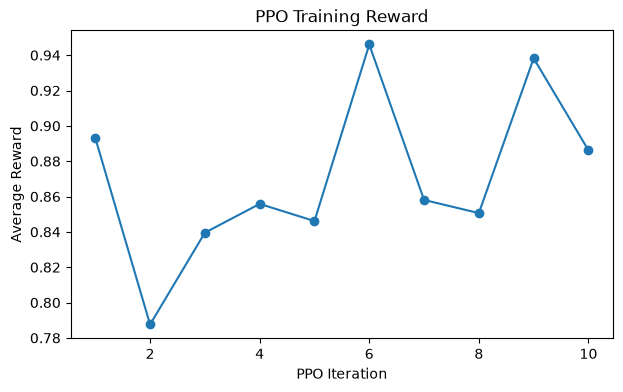

In [171]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 4))

plt.plot(
    range(1, num_iterations + 1),
    ppo_reward_history,
    marker="o"
)

plt.xlabel("PPO Iteration")
plt.ylabel("Average Reward")
plt.title("PPO Training Reward")

plt.show()

In [192]:
import copy

ppo_model = copy.deepcopy(model).to(device)

ppo_optimizer = torch.optim.Adam(
    ppo_model.parameters(),
    lr=1e-5
)

value_model = ValueNetwork().to(device)

value_optimizer = torch.optim.Adam(
    value_model.parameters(),
    lr=1e-4
)

In [193]:
eval_noise = torch.randn(
    128, 1, 28, 28,
    device=device
)

In [194]:
@torch.no_grad()
def evaluate_model(model, eval_noise):
    samples = sample_ddpm(model, eval_noise)
    rewards, classes = get_reward(samples)

    return (
        rewards.mean().item(),
        rewards.std().item(),
        classes
    )

In [195]:
baseline_eval_reward, baseline_eval_std, _ = evaluate_model(
    model,
    eval_noise
)

print("Baseline:", baseline_eval_reward)

Baseline: 0.9009866714477539


In [196]:
num_iterations = 20

train_reward_history = []
eval_reward_history = []

for iteration in range(num_iterations):

    # -------------------------
    # Rollout
    # -------------------------

    trajectory, rewards, classes, _ = (
        collect_trajectory(
            ppo_model,
            batch_size=16,
            save_every=20
        )
    )

    # -------------------------
    # PPO update
    # -------------------------

    (
        policy_loss,
        value_loss,
        ratio_mean,
        clip_fraction
    ) = ppo_update(
        ppo_model,
        value_model,
        trajectory,
        rewards,
        ppo_optimizer,
        value_optimizer,
        clip_eps=0.2,
        ppo_epochs=4
    )

    train_reward = rewards.mean().item()

    # -------------------------
    # Fixed evaluation
    # -------------------------

    eval_reward, eval_std, _ = (
        evaluate_model(
            ppo_model,
            eval_noise
        )
    )

    train_reward_history.append(
        train_reward
    )

    eval_reward_history.append(
        eval_reward
    )

    print(
        f"[{iteration+1:02d}/{num_iterations}] "
        f"Train R: {train_reward:.4f} | "
        f"Eval R: {eval_reward:.4f} | "
        f"Policy: {policy_loss:.4f} | "
        f"Value: {value_loss:.4f} | "
        f"Ratio: {ratio_mean:.3f} | "
        f"Clip: {clip_fraction:.3f}"
    )

[01/20] Train R: 0.8027 | Eval R: 0.9087 | Policy: -0.0088 | Value: 0.2884 | Ratio: 1.000 | Clip: 0.004
[02/20] Train R: 0.8545 | Eval R: 0.9044 | Policy: -0.0040 | Value: 0.0451 | Ratio: 1.000 | Clip: 0.000
[03/20] Train R: 0.9126 | Eval R: 0.9188 | Policy: -0.0036 | Value: 0.0908 | Ratio: 1.001 | Clip: 0.000
[04/20] Train R: 0.8794 | Eval R: 0.9236 | Policy: -0.0020 | Value: 0.0578 | Ratio: 1.000 | Clip: 0.000
[05/20] Train R: 0.8692 | Eval R: 0.9140 | Policy: -0.0019 | Value: 0.0350 | Ratio: 1.000 | Clip: 0.000
[06/20] Train R: 0.9425 | Eval R: 0.9327 | Policy: -0.0021 | Value: 0.0518 | Ratio: 1.000 | Clip: 0.000
[07/20] Train R: 0.8609 | Eval R: 0.9259 | Policy: -0.0024 | Value: 0.0380 | Ratio: 1.000 | Clip: 0.000
[08/20] Train R: 0.9231 | Eval R: 0.9312 | Policy: -0.0023 | Value: 0.0236 | Ratio: 1.000 | Clip: 0.000
[09/20] Train R: 0.8636 | Eval R: 0.9166 | Policy: -0.0022 | Value: 0.0406 | Ratio: 1.000 | Clip: 0.000
[10/20] Train R: 0.8711 | Eval R: 0.9366 | Policy: -0.0019 | Val

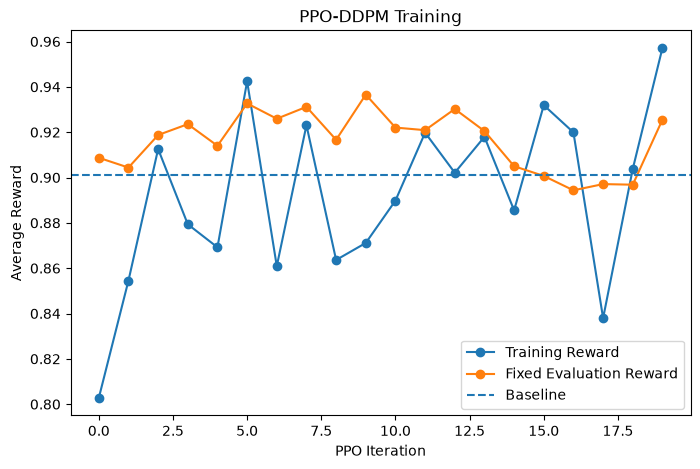

In [197]:
plt.figure(figsize=(8, 5))

plt.plot(
    train_reward_history,
    label="Training Reward",
    marker="o"
)

plt.plot(
    eval_reward_history,
    label="Fixed Evaluation Reward",
    marker="o"
)

plt.axhline(
    baseline_eval_reward,
    linestyle="--",
    label="Baseline"
)

plt.xlabel("PPO Iteration")
plt.ylabel("Average Reward")
plt.title("PPO-DDPM Training")
plt.legend()

plt.show()

In [198]:
# 처음 저장해둔 동일한 initial noise 불러오기
initial_noise = torch.load(
    "initial_noise.pt"
).to(device)

# Baseline
baseline_images = sample_ddpm(
    model,
    initial_noise
)

# 현재 PPO 모델
ppo_images = sample_ddpm(
    ppo_model,
    initial_noise
)

print("Baseline:", baseline_images.shape)
print("PPO:", ppo_images.shape)

Baseline: torch.Size([16, 1, 28, 28])
PPO: torch.Size([16, 1, 28, 28])


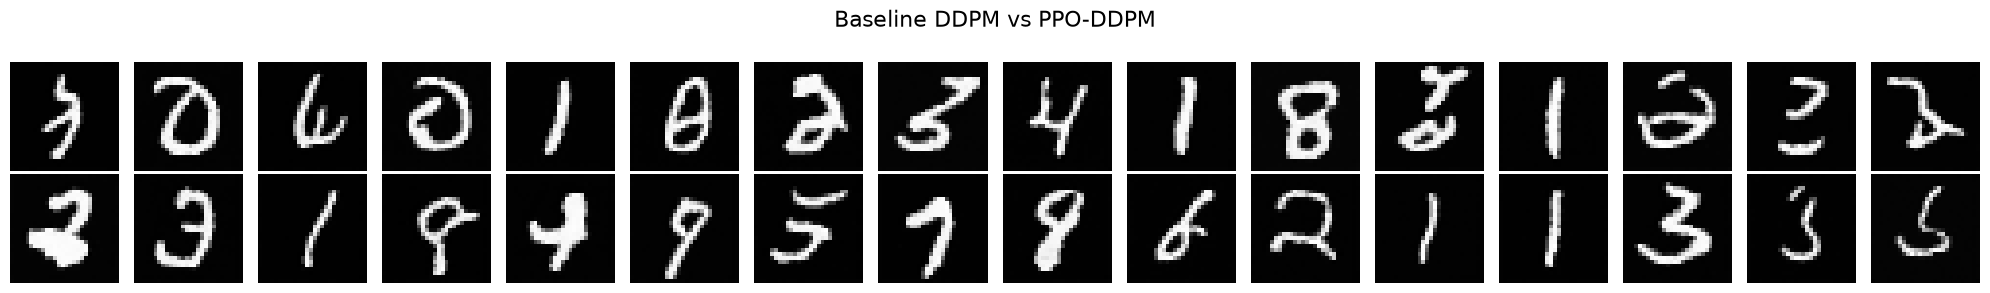

In [199]:
import matplotlib.pyplot as plt

num_samples = 16

fig, axes = plt.subplots(
    2,
    num_samples,
    figsize=(20, 3)
)

for i in range(num_samples):

    # Baseline
    axes[0, i].imshow(
        baseline_images[i]
        .squeeze()
        .detach()
        .cpu(),
        cmap="gray"
    )

    axes[0, i].axis("off")

    # PPO
    axes[1, i].imshow(
        ppo_images[i]
        .squeeze()
        .detach()
        .cpu(),
        cmap="gray"
    )

    axes[1, i].axis("off")


axes[0, 0].set_ylabel(
    "Baseline",
    fontsize=12
)

axes[1, 0].set_ylabel(
    "PPO",
    fontsize=12
)

plt.suptitle(
    "Baseline DDPM vs PPO-DDPM",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [200]:
@torch.no_grad()
def sample_ddpm_controlled(
    model,
    initial_noise,
    reverse_noises
):
    model.eval()

    x = initial_noise.clone().to(device)

    for t in reversed(range(T)):

        mean, variance = get_transition_stats(
            model,
            x,
            t
        )

        if t == 0:
            # 마지막 step은 noise를 추가하지 않음
            x = mean

        else:
            # 미리 만들어둔 동일한 noise 사용
            z = reverse_noises[t].to(device)

            x = (
                mean
                + torch.sqrt(variance) * z
            )

    return x

In [201]:
initial_noise = torch.load(
    "initial_noise.pt"
).to(device)

num_samples = initial_noise.shape[0]

# 모든 reverse timestep에서 사용할 noise를
# 한 번만 미리 생성
reverse_noises = torch.randn(
    T,
    num_samples,
    1,
    28,
    28
)

In [202]:
baseline_controlled = sample_ddpm_controlled(
    model,
    initial_noise,
    reverse_noises
)

ppo_controlled = sample_ddpm_controlled(
    ppo_model,
    initial_noise,
    reverse_noises
)

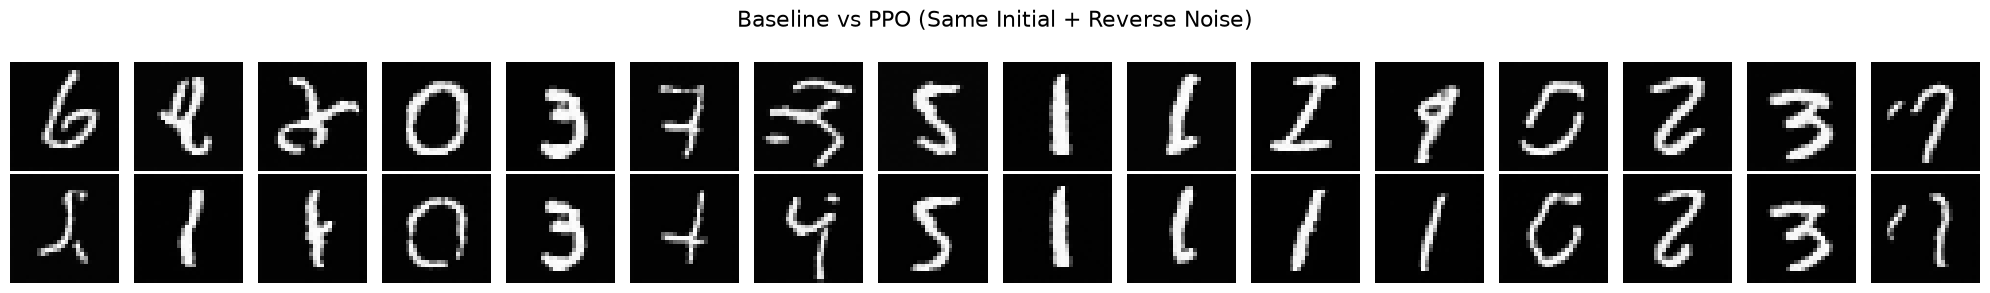

In [203]:
fig, axes = plt.subplots(
    2,
    num_samples,
    figsize=(20, 3)
)

for i in range(num_samples):

    # Baseline
    axes[0, i].imshow(
        baseline_controlled[i]
        .squeeze()
        .cpu(),
        cmap="gray"
    )

    axes[0, i].axis("off")

    # PPO
    axes[1, i].imshow(
        ppo_controlled[i]
        .squeeze()
        .cpu(),
        cmap="gray"
    )

    axes[1, i].axis("off")


axes[0, 0].set_ylabel(
    "Baseline",
    fontsize=12
)

axes[1, 0].set_ylabel(
    "PPO",
    fontsize=12
)

plt.suptitle(
    "Baseline vs PPO (Same Initial + Reverse Noise)",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [204]:
baseline_rewards, baseline_classes = get_reward(
    baseline_controlled
)

ppo_rewards, ppo_classes = get_reward(
    ppo_controlled
)

print("===== Baseline =====")
print("Classes :", baseline_classes)
print("Rewards :", baseline_rewards)
print(
    "Average Reward:",
    baseline_rewards.mean().item()
)

print()

print("===== PPO =====")
print("Classes :", ppo_classes)
print("Rewards :", ppo_rewards)
print(
    "Average Reward:",
    ppo_rewards.mean().item()
)

===== Baseline =====
Classes : tensor([6, 8, 8, 0, 3, 7, 3, 5, 1, 1, 2, 9, 5, 2, 3, 7], device='mps:0')
Rewards : tensor([1.0000, 0.5162, 0.9993, 0.9999, 0.9952, 0.9668, 0.5918, 0.9998, 0.9999,
        0.9698, 0.9985, 0.9547, 0.9015, 0.9968, 1.0000, 0.9959],
       device='mps:0')
Average Reward: 0.9303956031799316

===== PPO =====
Classes : tensor([2, 1, 4, 0, 3, 4, 4, 5, 1, 1, 1, 1, 6, 2, 3, 7], device='mps:0')
Rewards : tensor([0.8945, 1.0000, 0.7033, 0.9972, 0.9965, 0.9984, 0.9035, 0.9999, 1.0000,
        0.9839, 0.9999, 0.9991, 0.8134, 0.9578, 1.0000, 0.6935],
       device='mps:0')
Average Reward: 0.9338003396987915


In [205]:
@torch.no_grad()
def evaluate_large_scale(
    model,
    initial_noises,
    batch_size=100
):
    model.eval()

    all_rewards = []
    all_classes = []

    total = initial_noises.shape[0]

    for start in range(0, total, batch_size):

        end = min(
            start + batch_size,
            total
        )

        noise_batch = (
            initial_noises[start:end]
            .to(device)
        )

        samples = sample_ddpm(
            model,
            noise_batch
        )

        rewards, classes = get_reward(
            samples
        )

        all_rewards.append(
            rewards.cpu()
        )

        all_classes.append(
            classes.cpu()
        )

        print(
            f"{end}/{total} generated"
        )

    all_rewards = torch.cat(
        all_rewards
    )

    all_classes = torch.cat(
        all_classes
    )

    return (
        all_rewards,
        all_classes
    )

In [206]:
num_eval_samples = 1000

large_eval_noise = torch.randn(
    num_eval_samples,
    1,
    28,
    28
)

In [207]:
baseline_rewards_1000, baseline_classes_1000 = (
    evaluate_large_scale(
        model,
        large_eval_noise,
        batch_size=100
    )
)

100/1000 generated
200/1000 generated
300/1000 generated
400/1000 generated
500/1000 generated
600/1000 generated
700/1000 generated
800/1000 generated
900/1000 generated
1000/1000 generated


In [208]:
ppo_rewards_1000, ppo_classes_1000 = (
    evaluate_large_scale(
        ppo_model,
        large_eval_noise,
        batch_size=100
    )
)

100/1000 generated
200/1000 generated
300/1000 generated
400/1000 generated
500/1000 generated
600/1000 generated
700/1000 generated
800/1000 generated
900/1000 generated
1000/1000 generated


In [209]:
print("===== Baseline =====")
print(
    "Mean Reward:",
    baseline_rewards_1000.mean().item()
)
print(
    "Std Reward:",
    baseline_rewards_1000.std().item()
)

print()

print("===== PPO =====")
print(
    "Mean Reward:",
    ppo_rewards_1000.mean().item()
)
print(
    "Std Reward:",
    ppo_rewards_1000.std().item()
)

===== Baseline =====
Mean Reward: 0.915411114692688
Std Reward: 0.14753662049770355

===== PPO =====
Mean Reward: 0.9203444719314575
Std Reward: 0.14606250822544098


In [210]:
baseline_counts = torch.bincount(
    baseline_classes_1000,
    minlength=10
)

ppo_counts = torch.bincount(
    ppo_classes_1000,
    minlength=10
)

print(
    "Baseline:",
    baseline_counts
)

print(
    "PPO:",
    ppo_counts
)

Baseline: tensor([ 50,  73, 148, 125, 103, 135, 113,  99,  76,  78])
PPO: tensor([ 17, 211,  93,  73, 127, 110,  89, 123,  61,  96])


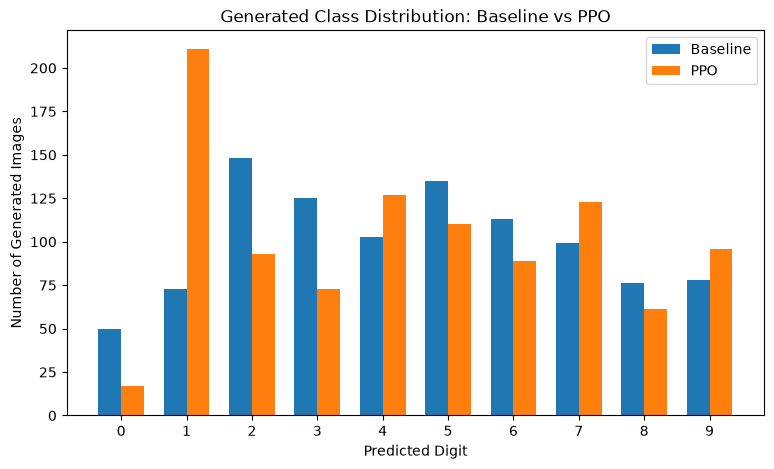

In [211]:
import numpy as np
import matplotlib.pyplot as plt

digits = np.arange(10)

width = 0.35

plt.figure(
    figsize=(9, 5)
)

plt.bar(
    digits - width/2,
    baseline_counts.numpy(),
    width=width,
    label="Baseline"
)

plt.bar(
    digits + width/2,
    ppo_counts.numpy(),
    width=width,
    label="PPO"
)

plt.xlabel("Predicted Digit")
plt.ylabel("Number of Generated Images")
plt.title(
    "Generated Class Distribution: Baseline vs PPO"
)

plt.xticks(digits)
plt.legend()

plt.show()

In [212]:
@torch.no_grad()
def sample_and_save_trajectory(
    model,
    initial_noise,
    reverse_noises,
    save_timesteps
):
    model.eval()

    x = initial_noise.clone().to(device)

    trajectory = {}

    # 시작점 x_T 저장
    trajectory[T] = x.detach().cpu().clone()

    for t in reversed(range(T)):

        mean, variance = get_transition_stats(
            model,
            x,
            t
        )

        if t == 0:
            x = mean

        else:
            z = reverse_noises[t].to(device)

            x = (
                mean
                + torch.sqrt(variance) * z
            )

        # 현재 reverse step 이후 상태 저장
        if t in save_timesteps:
            trajectory[t] = (
                x.detach().cpu().clone()
            )

    return x, trajectory

In [213]:
save_timesteps = [
    900,
    800,
    700,
    600,
    500,
    400,
    300,
    200,
    100,
    50,
    20,
    10,
    0
]

In [214]:
initial_noise = torch.load(
    "initial_noise.pt"
).to(device)

num_samples = initial_noise.shape[0]

print(initial_noise.shape)

torch.Size([16, 1, 28, 28])


In [215]:
torch.manual_seed(42)

reverse_noises = torch.randn(
    T,
    num_samples,
    1,
    28,
    28
)

In [216]:
torch.save(
    reverse_noises,
    "trajectory_reverse_noises.pt"
)

In [217]:
baseline_final, baseline_trajectory = (
    sample_and_save_trajectory(
        model,
        initial_noise,
        reverse_noises,
        save_timesteps
    )
)

ppo_final, ppo_trajectory = (
    sample_and_save_trajectory(
        ppo_model,
        initial_noise,
        reverse_noises,
        save_timesteps
    )
)

In [218]:
torch.save(
    baseline_trajectory,
    "baseline_trajectory.pt"
)

torch.save(
    ppo_trajectory,
    "ppo_trajectory.pt"
)

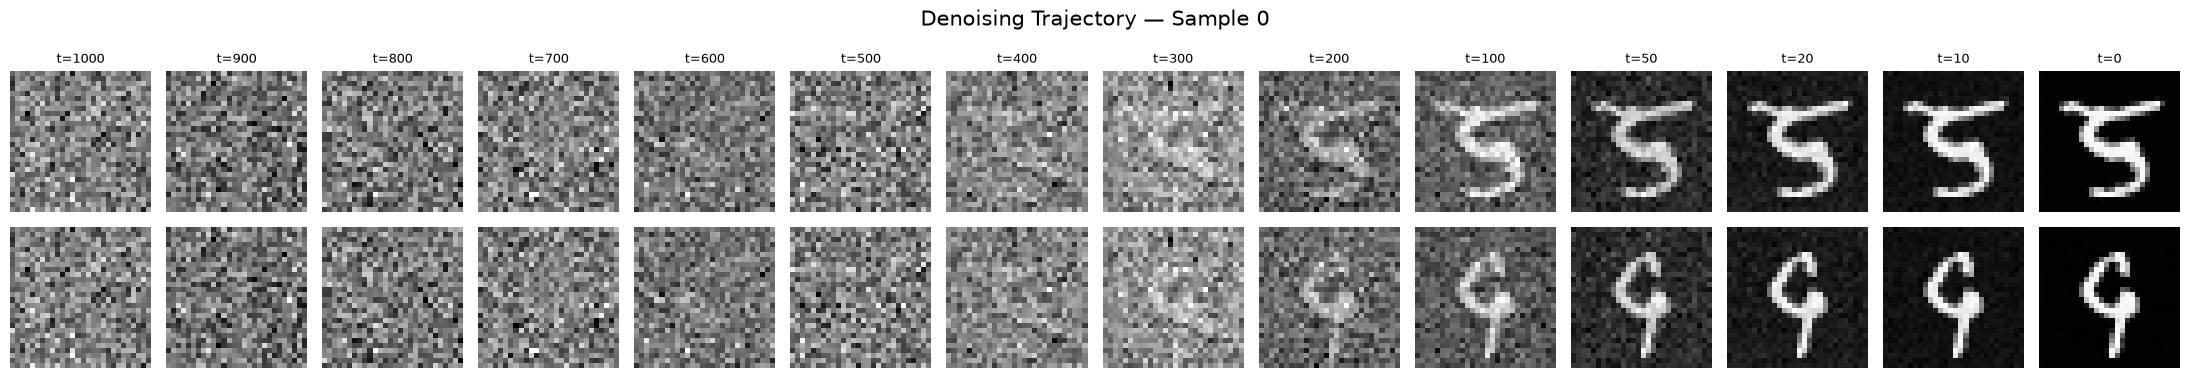

In [221]:
sample_idx = 1

timesteps_to_show = [
    T,
    900,
    800,
    700,
    600,
    500,
    400,
    300,
    200,
    100,
    50,
    20,
    10,
    0
]

fig, axes = plt.subplots(
    2,
    len(timesteps_to_show),
    figsize=(22, 4)
)

for j, t in enumerate(timesteps_to_show):

    # Baseline
    baseline_img = (
        baseline_trajectory[t][sample_idx]
        .squeeze()
    )

    axes[0, j].imshow(
        baseline_img,
        cmap="gray"
    )

    axes[0, j].axis("off")
    axes[0, j].set_title(
        f"t={t}",
        fontsize=9
    )

    # PPO
    ppo_img = (
        ppo_trajectory[t][sample_idx]
        .squeeze()
    )

    axes[1, j].imshow(
        ppo_img,
        cmap="gray"
    )

    axes[1, j].axis("off")


axes[0, 0].set_ylabel(
    "Baseline",
    fontsize=12
)

axes[1, 0].set_ylabel(
    "PPO",
    fontsize=12
)

plt.suptitle(
    "Denoising Trajectory — Sample 0",
    fontsize=15
)

plt.tight_layout()
plt.show()

In [220]:
baseline_rewards, baseline_classes = get_reward(
    baseline_final
)

ppo_rewards, ppo_classes = get_reward(
    ppo_final
)

for i in range(16):
    changed = (
        baseline_classes[i].item()
        != ppo_classes[i].item()
    )

    print(
        f"{i:2d} | "
        f"Baseline: {baseline_classes[i].item()} "
        f"→ PPO: {ppo_classes[i].item()} "
        f"{'*** CHANGED ***' if changed else ''}"
    )

 0 | Baseline: 4 → PPO: 4 
 1 | Baseline: 5 → PPO: 9 *** CHANGED ***
 2 | Baseline: 7 → PPO: 7 
 3 | Baseline: 6 → PPO: 6 
 4 | Baseline: 4 → PPO: 6 *** CHANGED ***
 5 | Baseline: 2 → PPO: 2 
 6 | Baseline: 3 → PPO: 8 *** CHANGED ***
 7 | Baseline: 1 → PPO: 1 
 8 | Baseline: 6 → PPO: 6 
 9 | Baseline: 2 → PPO: 2 
10 | Baseline: 7 → PPO: 7 
11 | Baseline: 9 → PPO: 9 
12 | Baseline: 6 → PPO: 6 
13 | Baseline: 5 → PPO: 5 
14 | Baseline: 8 → PPO: 1 *** CHANGED ***
15 | Baseline: 2 → PPO: 2 


In [222]:
@torch.no_grad()
def save_detailed_trajectory(
    model,
    initial_noise,
    reverse_noises,
    save_timesteps
):
    model.eval()

    x = initial_noise.clone().to(device)

    trajectory = {}

    for t in reversed(range(T)):

        mean, variance = get_transition_stats(
            model,
            x,
            t
        )

        if t == 0:
            x = mean

        else:
            z = reverse_noises[t].to(device)

            x = (
                mean
                + torch.sqrt(variance) * z
            )

        if t in save_timesteps:
            trajectory[t] = (
                x.detach().cpu().clone()
            )

    return trajectory

In [223]:
detailed_timesteps = list(
    range(400, -1, -25)
)

print(detailed_timesteps)

[400, 375, 350, 325, 300, 275, 250, 225, 200, 175, 150, 125, 100, 75, 50, 25, 0]


In [224]:
initial_noise = torch.load(
    "initial_noise.pt"
).to(device)

reverse_noises = torch.load(
    "trajectory_reverse_noises.pt"
)

baseline_detailed = save_detailed_trajectory(
    model,
    initial_noise,
    reverse_noises,
    detailed_timesteps
)

ppo_detailed = save_detailed_trajectory(
    ppo_model,
    initial_noise,
    reverse_noises,
    detailed_timesteps
)

In [225]:
torch.save(
    baseline_detailed,
    "baseline_detailed_trajectory.pt"
)

torch.save(
    ppo_detailed,
    "ppo_detailed_trajectory.pt"
)

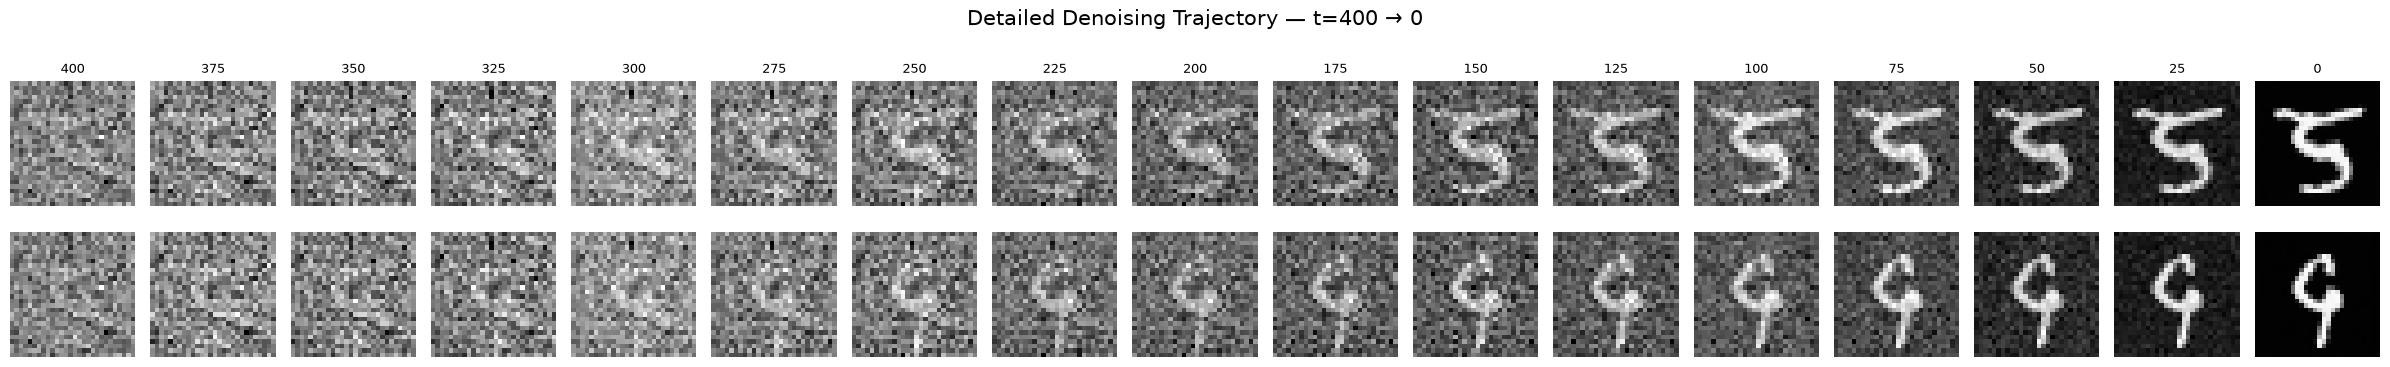

In [226]:
sample_idx = 1

fig, axes = plt.subplots(
    2,
    len(detailed_timesteps),
    figsize=(24, 4)
)

for j, t in enumerate(detailed_timesteps):

    # Baseline
    axes[0, j].imshow(
        baseline_detailed[t][sample_idx].squeeze(),
        cmap="gray"
    )

    axes[0, j].axis("off")
    axes[0, j].set_title(
        f"{t}",
        fontsize=9
    )

    # PPO
    axes[1, j].imshow(
        ppo_detailed[t][sample_idx].squeeze(),
        cmap="gray"
    )

    axes[1, j].axis("off")


axes[0, 0].set_ylabel(
    "Baseline",
    fontsize=12
)

axes[1, 0].set_ylabel(
    "PPO",
    fontsize=12
)

plt.suptitle(
    "Detailed Denoising Trajectory — t=400 → 0",
    fontsize=15
)

plt.tight_layout()
plt.show()

In [227]:
zoom_timesteps = list(
    range(400, 249, -10)
)

print(zoom_timesteps)

[400, 390, 380, 370, 360, 350, 340, 330, 320, 310, 300, 290, 280, 270, 260, 250]


In [228]:
baseline_zoom = save_detailed_trajectory(
    model,
    initial_noise,
    reverse_noises,
    zoom_timesteps
)

ppo_zoom = save_detailed_trajectory(
    ppo_model,
    initial_noise,
    reverse_noises,
    zoom_timesteps
)

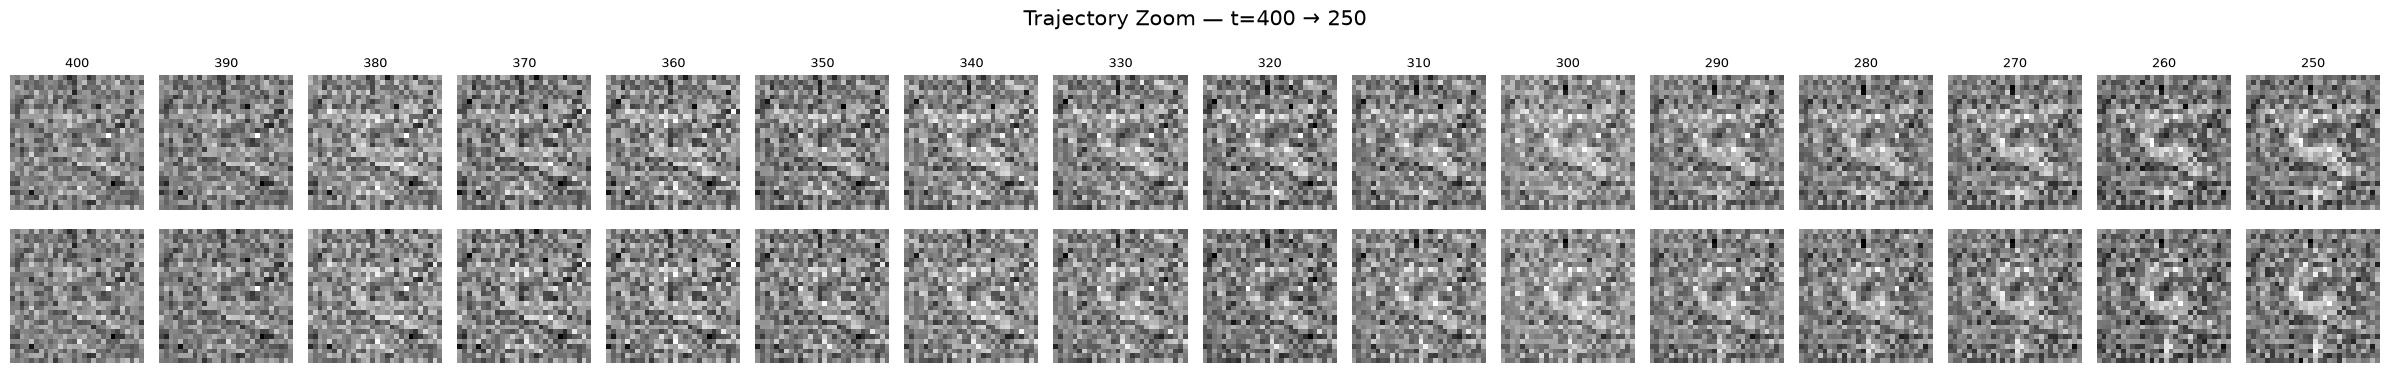

In [229]:
sample_idx = 1

fig, axes = plt.subplots(
    2,
    len(zoom_timesteps),
    figsize=(24, 4)
)

for j, t in enumerate(zoom_timesteps):

    # Baseline
    axes[0, j].imshow(
        baseline_zoom[t][sample_idx].squeeze(),
        cmap="gray"
    )
    axes[0, j].axis("off")
    axes[0, j].set_title(
        f"{t}",
        fontsize=9
    )

    # PPO
    axes[1, j].imshow(
        ppo_zoom[t][sample_idx].squeeze(),
        cmap="gray"
    )
    axes[1, j].axis("off")


axes[0, 0].set_ylabel(
    "Baseline",
    fontsize=12
)

axes[1, 0].set_ylabel(
    "PPO",
    fontsize=12
)

plt.suptitle(
    "Trajectory Zoom — t=400 → 250",
    fontsize=15
)

plt.tight_layout()
plt.show()

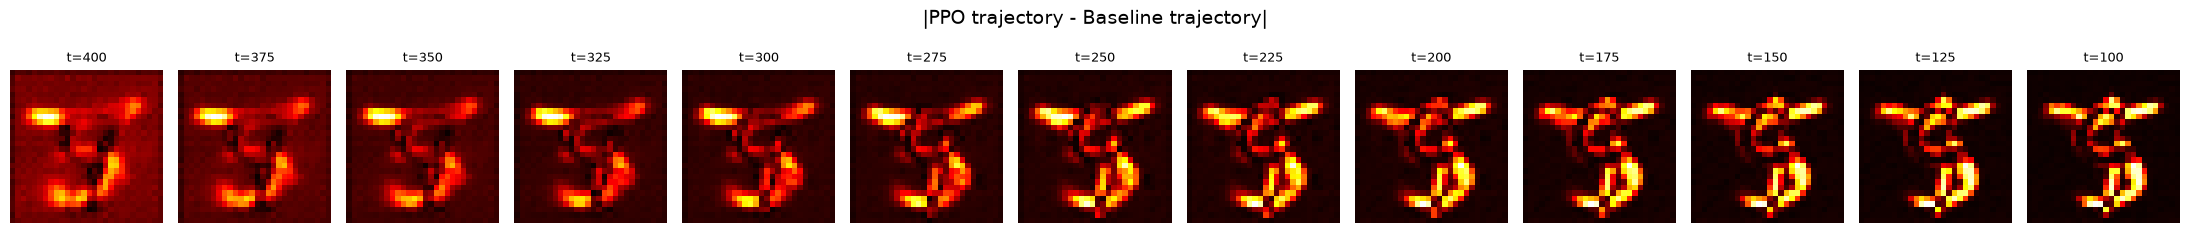

In [232]:
sample_idx = 1

difference_timesteps = [
    400, 375, 350, 325,
    300, 275, 250,
    225, 200, 175,
    150, 125, 100
]

fig, axes = plt.subplots(
    1,
    len(difference_timesteps),
    figsize=(22, 2.5)
)

for j, t in enumerate(difference_timesteps):

    # 기존 detailed에 없는 timestep이 있을 수 있으므로
    # trajectory_distances가 아니라 이미지를 다시 가져오기 위해
    # 해당 timestep trajectory 생성
    base = baseline_detailed.get(t)
    ppo = ppo_detailed.get(t)

    if base is None:
        continue

    diff = torch.abs(
        ppo[sample_idx]
        - base[sample_idx]
    ).squeeze()

    axes[j].imshow(
        diff,
        cmap="hot"
    )

    axes[j].axis("off")
    axes[j].set_title(
        f"t={t}",
        fontsize=9
    )

plt.suptitle(
    "|PPO trajectory - Baseline trajectory|",
    fontsize=14
)

plt.tight_layout()
plt.show()

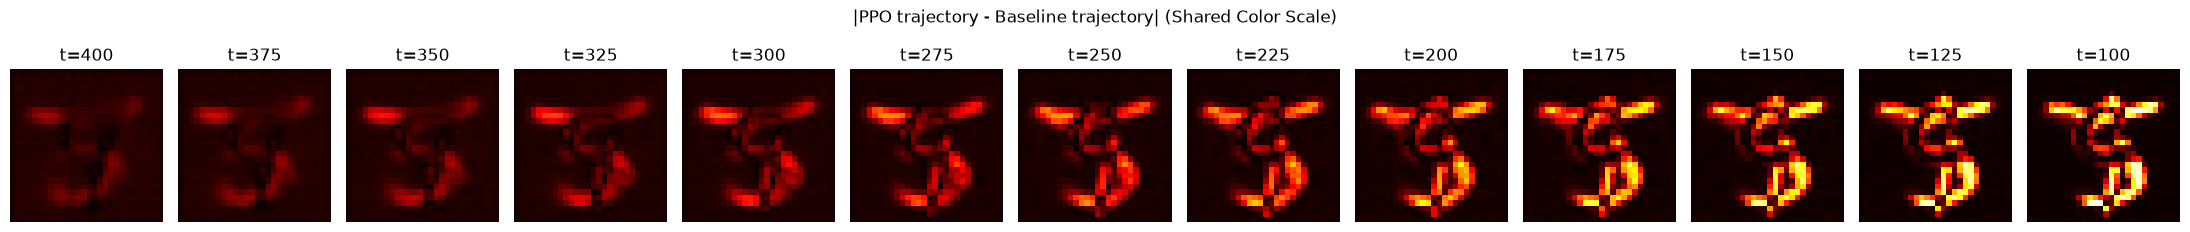

In [231]:
sample_idx = 1
difference_timesteps = [
    400, 375, 350, 325,
    300, 275, 250,
    225, 200, 175,
    150, 125, 100
]

diff_maps = []

for t in difference_timesteps:

    diff = torch.abs(
        ppo_detailed[t][sample_idx]
        - baseline_detailed[t][sample_idx]
    ).squeeze()

    diff_maps.append(diff)


# 모든 timestep에 동일한 scale
global_max = max(
    diff.max().item()
    for diff in diff_maps
)


fig, axes = plt.subplots(
    1,
    len(difference_timesteps),
    figsize=(22, 2.5)
)

for j, (t, diff) in enumerate(
    zip(difference_timesteps, diff_maps)
):

    axes[j].imshow(
        diff,
        cmap="hot",
        vmin=0,
        vmax=global_max
    )

    axes[j].axis("off")
    axes[j].set_title(f"t={t}")


plt.suptitle(
    "|PPO trajectory - Baseline trajectory| "
    "(Shared Color Scale)"
)

plt.tight_layout()
plt.show()

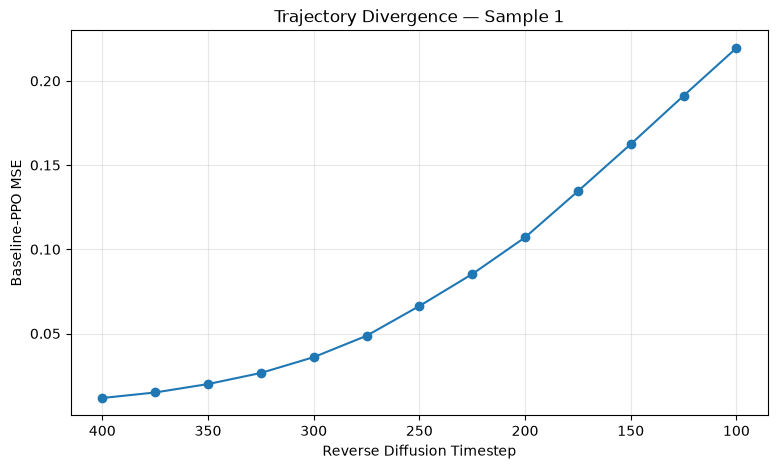

In [234]:
sample_idx = 1

mse_timesteps = [
    400, 375, 350, 325,
    300, 275, 250,
    225, 200, 175,
    150, 125, 100
]

mse_values = []

for t in mse_timesteps:

    base = baseline_detailed[t][sample_idx]
    ppo = ppo_detailed[t][sample_idx]

    mse = torch.mean(
        (ppo - base) ** 2
    ).item()

    mse_values.append(mse)


plt.figure(figsize=(9, 5))

plt.plot(
    mse_timesteps,
    mse_values,
    marker="o"
)

plt.gca().invert_xaxis()

plt.xlabel("Reverse Diffusion Timestep")
plt.ylabel("Baseline-PPO MSE")
plt.title(
    "Trajectory Divergence — Sample 1"
)

plt.grid(alpha=0.3)

plt.show()